<a href="https://colab.research.google.com/github/fernandodeeke/sistemas_dinamicos/blob/main/SD_Python1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Autovalores:
[ 3. -1.]

Autovetores (colunas):
[[ 0.4472136  -0.4472136 ]
 [ 0.89442719  0.89442719]]


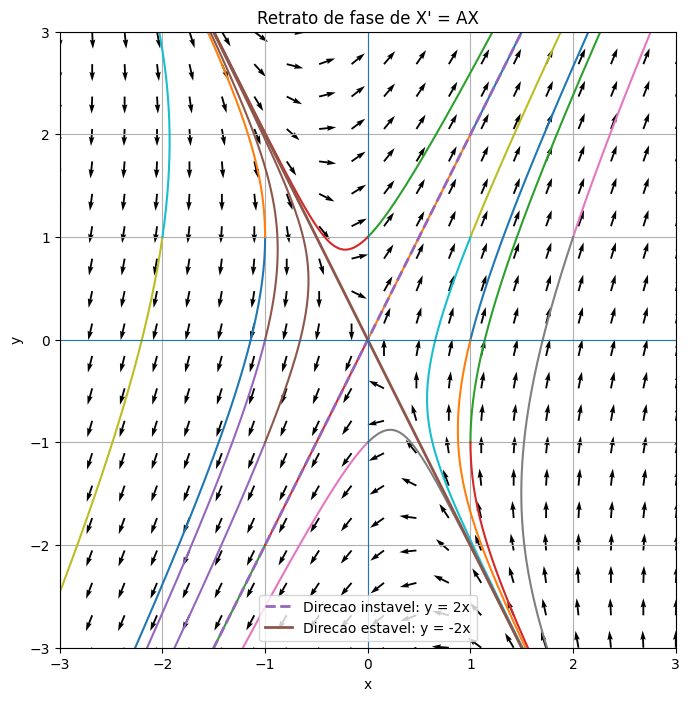

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Matriz do sistema
A = np.array([[1, 1],
              [4, 1]])

# Autovalores e autovetores
vals, vecs = np.linalg.eig(A)

print("Autovalores:")
print(vals)
print("\nAutovetores (colunas):")
print(vecs)

# Sistema X' = AX
def sistema(t, X):
    return A @ X

# Malha para o campo vetorial
x = np.linspace(-3, 3, 20)
y = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x, y)

U = A[0,0]*X + A[0,1]*Y
V = A[1,0]*X + A[1,1]*Y

# Normalizacao das setas
N = np.sqrt(U**2 + V**2)
N[N == 0] = 1
U2 = U / N
V2 = V / N

plt.figure(figsize=(8, 8))
plt.quiver(X, Y, U2, V2, angles='xy')

# Condicoes iniciais
condicoes_iniciais = [
    [1, 0], [0, 1], [-1, 0], [0, -1],
    [1, 1], [-1, 1], [1, -1], [-1, -1],
    [2, 1], [-2, 1], [1, 2], [-1, -2]
]

t_span_forward = (0, 2)
t_span_backward = (0, -2)
t_eval_forward = np.linspace(0, 2, 400)
t_eval_backward = np.linspace(0, -2, 400)

for X0 in condicoes_iniciais:
    sol_f = solve_ivp(sistema, t_span_forward, X0, t_eval=t_eval_forward)
    sol_b = solve_ivp(sistema, t_span_backward, X0, t_eval=t_eval_backward)

    plt.plot(sol_f.y[0], sol_f.y[1])
    plt.plot(sol_b.y[0], sol_b.y[1])

# Retas dos autovetores
s = np.linspace(-3, 3, 200)
plt.plot(s, 2*s, '--', linewidth=2, label='Direcao instavel: y = 2x')
plt.plot(s, -2*s, '-', linewidth=2, label='Direcao estavel: y = -2x')

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.xlabel('x')
plt.ylabel('y')
plt.title("Retrato de fase de X' = AX")
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal')
plt.show()